# PROJEKTI: Liikenneonnettomuudet Suomessa vuosina 2022-2024

## Liiketoiminnan ymmärrys

Projektissa analysoimme Suomessa vuosina 2022-2024 tapahtuneita liikenneonnettomuuksia. Analysoimamme aineisto sisältää vain tapahtuneet onnettomuudet, joten sen perusteella ei voi arvioida kuinka todennäköisesti onnettomuus tapahtuu. Tuloksista voisi olla hyötyä esimerkiksi ensihoidolle ja hyvinvointialueille.

Tavoitteena on vastata kahteen kysymykseen:
1. Voiko onnettomuuden vakavuuden ennustaa onnettomuuden ominaisuuksien perusteella?
2. Miten ensiapuyksiköt pitäisi sijoittaa Uudellamaalla, jotta onnettomuuksiin voidaan reagoida mahdollisimman tehokkaasti?

Ensimmäiseen kysymykseen vastaamme satunnaismetsämallilla. Vakavuutta voidaan pitää ennustettavana, jos malli tunnistaa loukkaantumiseen tai kuolemaan johtaneet onnettomuudet selvästi paremmin kuin pelkkä yleisimmän luokan arvaaminen. Mallin tuloksista näemme lisäksi, mitkä ominaisuudet vaikuttavat ennusteisiin eniten.

Toiseen kysymykseen vastaamme klusteroimalla Uudellamaalla tapahtuneiden henkilövahinkoon johtaneiden onnettomuuksien sijainnit. Klusterit kuvaavat ensiapuyksiköiden vastuualueita ja keskipisteet niiden sijoituspaikkoja. Vertailemme K-means-klusterointia ja hierarkkista klusterointia. Tulos on hyväksyttävä, jos silhouette score on yli 0,50.

## Datan ymmärrys Nur

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [2]:
df1 = pd.read_csv('datasets/tieliikenneonnettomuudet_2024/tieliikenneonnettomuudet_2024_onnettomuudet.csv', sep=';', na_values=['', ' ', '-'])
df1

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,Elinvoimakeskus,ELY-keskus,Maakunta (koordinaattien perusteella),Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Nro,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
0,630347,Väylävirasto,4/414/15609,2.0,4.0,414.0,15609.0,416968.0,7274492.0,NaN,Pohjois-Suomen elinvoimakeskus,Pohjois-Pohjanmaan ELY,Pohjois-Pohjanmaa,Ii,KEMINTIE,2024,1,muu peräänajo liikkuvaan ajoneuvoon,7,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,ajourat paljaat,pimeä (valaisematon),−25,kirkas,100.0,Tieto puuttuu,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei
1,630348,Väylävirasto,775/23/6441,0.0,775.0,23.0,6441.0,416349.0,7013202.0,NaN,Keski-Suomen elinvoimakeskus,Keski-Suomen ELY,Keski-Suomi,Viitasaari,KOKKOLANTIE,2024,1,eläinonnettomuus,90,Ei henkilövahinkoja,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,luminen,pimeä (valaisematon),−30,kirkas,80.0,NaN,kestopäällyste,Ic,Seututie,Ei tasoristeystä,ei
2,630349,Kunta,NaN,NaN,NaN,NaN,NaN,483623.0,6748126.0,NaN,Kaakkois-Suomen elinvoimakeskus,Kaakkois-Suomen ELY,Kymenlaakso,Kouvola,LIIKEMIEHENKATU,2024,1,vastakkaiset ajosuunnat muu törmäys käännyttäe...,36,Ei henkilövahinkoja,kääntymisonnettomuus,ei,ei,ajorata,kärkikolmio,ma,luminen,tie valaistu,−15,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
3,630350,Väylävirasto,210/6/633,0.0,210.0,6.0,633.0,265591.0,6755057.0,NaN,Lounais-Suomen elinvoimakeskus,Varsinais-Suomen ELY,Varsinais-Suomi,Oripää,YLÄNEENTIE X SAVOTTAKUJA,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,jäinen,pimeä (valaisematon),−19,kirkas,40.0,NaN,kestopäällyste,Ib,Seututie,Ei tasoristeystä,kyllä
4,630351,Kunta,NaN,NaN,NaN,NaN,NaN,331806.0,6819789.0,NaN,Sisä-Suomen elinvoimakeskus,Pirkanmaan ELY,Pirkanmaa,Tampere,MARTINPOJANKATU,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,pysäköintialue tai piha,linjaonnettomuus,ma,luminen,hämärä,−20,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,642006,Muu,NaN,NaN,NaN,NaN,NaN,433882.0,6943866.0,NaN,Keski-Suomen elinvoimakeskus,Keski-Suomen ELY,Keski-Suomi,Äänekoski,Niinimäenkatu 15,2024,7,muu jalankulkuonnettomuus suojatien ulkopuolella,79,Kuolemaan johtanut,jalankulkijaonnettomuus,ei,ei,pysäköintialue tai piha,linjaonnettomuus,to,NaN,päivänvalo,25,raesade,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
8825,642772,Kunta,NaN,NaN,NaN,NaN,NaN,375253.0,6672454.0,toiminnassa,Uudenmaan elinvoimakeskus,Uudenmaan ELY,Uusimaa,Espoo,Kuitinmäentie x Kilonväylä,2024,8,peräänajo liikenne-esteen takia pysäht. ajoneu...,8,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,liikennevalot,ke,"paljas, kuiva",päivänvalo,22,raesade,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
8826,642878,Väylävirasto,51/9/3473,0.0,51.0,9.0,3473.0,354570.0,6666569.0,NaN,Uudenmaan elinvoimakeskus,Uudenmaan ELY,Uusimaa,Kirkkonummi,Tie 51 x Karlbergintie,2024,1,ajo risteäviä ajosuuntia suoraan,40,Ei henkilövahinkoja,risteämisonnettomuus,ei,ei,ajorata,kärkikolmio,pe,luminen,tie valaistu,−8,pilvipouta,80.0,Tieto puuttuu,kestopäällyste,Ise,Kantatie,Ei tasoristeystä,ei
8827,646508,Kunta,NaN,NaN,NaN,NaN,NaN,362877.0,6766453.0,NaN,Sisä-Suomen elinvoimakeskus,Uudenmaan ELY,Kanta-Häme,Hämeenlinna,VANERITEHTAANTIEN TASORISTEYS,2024,4,junan ja jalankulkijan törmäys,76,Kuolemaan johtanut,jalankulkijaonnettomuus,ei,ei,kävely- ja pyörätie,linjaonnettomuus,to,NaN,hämärä,1,raesade,40.0,NaN,sora,NaN,Katu/Yksityistie,Ääni- ja va

In [3]:
df1= df1.rename(columns={'Maakunta (koordinaattien perusteella)' : 'Maakunta', 'Nro' : 'Onnettomuustyyppi nro'})
df1 = df1.drop(columns='Elinvoimakeskus')
df1

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi nro,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
0,630347,Väylävirasto,4/414/15609,2.0,4.0,414.0,15609.0,416968.0,7274492.0,NaN,Pohjois-Pohjanmaan ELY,Pohjois-Pohjanmaa,Ii,KEMINTIE,2024,1,muu peräänajo liikkuvaan ajoneuvoon,7,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,ajourat paljaat,pimeä (valaisematon),−25,kirkas,100.0,Tieto puuttuu,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei
1,630348,Väylävirasto,775/23/6441,0.0,775.0,23.0,6441.0,416349.0,7013202.0,NaN,Keski-Suomen ELY,Keski-Suomi,Viitasaari,KOKKOLANTIE,2024,1,eläinonnettomuus,90,Ei henkilövahinkoja,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,luminen,pimeä (valaisematon),−30,kirkas,80.0,NaN,kestopäällyste,Ic,Seututie,Ei tasoristeystä,ei
2,630349,Kunta,NaN,NaN,NaN,NaN,NaN,483623.0,6748126.0,NaN,Kaakkois-Suomen ELY,Kymenlaakso,Kouvola,LIIKEMIEHENKATU,2024,1,vastakkaiset ajosuunnat muu törmäys käännyttäe...,36,Ei henkilövahinkoja,kääntymisonnettomuus,ei,ei,ajorata,kärkikolmio,ma,luminen,tie valaistu,−15,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
3,630350,Väylävirasto,210/6/633,0.0,210.0,6.0,633.0,265591.0,6755057.0,NaN,Varsinais-Suomen ELY,Varsinais-Suomi,Oripää,YLÄNEENTIE X SAVOTTAKUJA,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,jäinen,pimeä (valaisematon),−19,kirkas,40.0,NaN,kestopäällyste,Ib,Seututie,Ei tasoristeystä,kyllä
4,630351,Kunta,NaN,NaN,NaN,NaN,NaN,331806.0,6819789.0,NaN,Pirkanmaan ELY,Pirkanmaa,Tampere,MARTINPOJANKATU,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,pysäköintialue tai piha,linjaonnettomuus,ma,luminen,hämärä,−20,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,642006,Muu,NaN,NaN,NaN,NaN,NaN,433882.0,6943866.0,NaN,Keski-Suomen ELY,Keski-Suomi,Äänekoski,Niinimäenkatu 15,2024,7,muu jalankulkuonnettomuus suojatien ulkopuolella,79,Kuolemaan johtanut,jalankulkijaonnettomuus,ei,ei,pysäköintialue tai piha,linjaonnettomuus,to,NaN,päivänvalo,25,raesade,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
8825,642772,Kunta,NaN,NaN,NaN,NaN,NaN,375253.0,6672454.0,toiminnassa,Uudenmaan ELY,Uusimaa,Espoo,Kuitinmäentie x Kilonväylä,2024,8,peräänajo liikenne-esteen takia pysäht. ajoneu...,8,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,liikennevalot,ke,"paljas, kuiva",päivänvalo,22,raesade,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
8826,642878,Väylävirasto,51/9/3473,0.0,51.0,9.0,3473.0,354570.0,6666569.0,NaN,Uudenmaan ELY,Uusimaa,Kirkkonummi,Tie 51 x Karlbergintie,2024,1,ajo risteäviä ajosuuntia suoraan,40,Ei henkilövahinkoja,risteämisonnettomuus,ei,ei,ajorata,kärkikolmio,pe,luminen,tie valaistu,−8,pilvipouta,80.0,Tieto puuttuu,kestopäällyste,Ise,Kantatie,Ei tasoristeystä,ei
8827,646508,Kunta,NaN,NaN,NaN,NaN,NaN,362877.0,6766453.0,NaN,Uudenmaan ELY,Kanta-Häme,Hämeenlinna,VANERITEHTAANTIEN TASORISTEYS,2024,4,junan ja jalankulkijan törmäys,76,Kuolemaan johtanut,jalankulkijaonnettomuus,ei,ei,kävely- ja pyörätie,linjaonnettomuus,to,NaN,hämärä,1,raesade,40.0,NaN,sora,NaN,Katu/Yksityistie,Ääni- ja valolaitteet,kyllä


In [4]:
df2 = pd.read_csv('datasets/tieliikenneonnettomuudet_2023/tieliikenneonnettomuudet_2023_onnettomuudet.csv', sep=';', na_values=['', ' ', '-'])
df2

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi nro,Vakavuus,Osallisten lkm,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama,KVL,KVL raskas,Näkemä% yli 150,Näkemä% yli 300,Näkemä% yli 450,Näkemän pituus
0,620587,Kunta,NaN,NaN,NaN,NaN,NaN,383804.0,6677861.0,NaN,NaN,NaN,NaN,ILKANTIE X METSÄLÄNTIE,2023,1,vastakkaiset ajosuunnat muu törmäys käännyttäe...,36,Loukkaantumiseen johtanut,2,kääntymisonnettomuus,ei,ei,ajorata,kärkikolmio,su,jäinen,tie valaistu,2,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä,NaN,NaN,NaN,NaN,NaN,NaN
1,620588,Väylävirasto,20.6.2500,0.0,20.0,6.0,2500.0,444876.0,7224084.0,NaN,Pohjois-Pohjanmaan ELY,Pohjois-Pohjanmaa,Oulu,Kuusamontie,2023,1,ohitus,0,Ei henkilövahinkoja,2,ohitusonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,luminen,pimeä (valaisematon),−1,lumisade,80.0,NaN,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei,3 970,494,99.0,92.0,68.0,NaN
2,620589,Väylävirasto,261/6/2322,0.0,261.0,6.0,2322.0,281069.0,6857041.0,NaN,Pirkanmaan ELY,Pirkanmaa,Ikaalinen,JÄMIJÄRVENTIE,2023,1,eläinonnettomuus,90,Ei henkilövahinkoja,2,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,pimeä (valaisematon),−5,pilvipouta,80.0,NaN,kestopäällyste,Ib,Seututie,Ei tasoristeystä,ei,1 512,132,93.0,49.0,22.0,NaN
3,620590,Väylävirasto,65/6/436,0.0,65.0,6.0,436.0,317770.0,6847910.0,NaN,Pirkanmaan ELY,Pirkanmaa,Ylöjärvi,UUSI-KURUNTIE,2023,1,eläinonnettomuus,90,Ei henkilövahinkoja,2,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,su,jäinen,pimeä (valaisematon),−5,kirkas,80.0,NaN,kestopäällyste,Is,Kantatie,Ei tasoristeystä,ei,3 873,279,73.0,31.0,8.0,NaN
4,620591,Väylävirasto,120/4/1101,0.0,120.0,4.0,1101.0,378049.0,6684830.0,NaN,Uudenmaan ELY,Uusimaa,Vantaa,Vihdintie,2023,1,suistuminen vasemmalle suoralla,81,Ei henkilövahinkoja,1,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,pimeä (valaisematon),−1,raesade,80.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei,9 027,418,85.0,48.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9086,631869,Kunta,NaN,NaN,NaN,NaN,NaN,440039.0,7377415.0,NaN,Pohjois-Pohjanmaan ELY,NaN,NaN,SUDENTIE 5,2023,12,suistuminen vasemmalle suoralla,81,Ei henkilövahinkoja,0,muu onnettomuus,ei,ei,ajorata,linjaonnettomuus,la,luminen,pimeä (valaisematon),−12,raesade,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä,NaN,NaN,NaN,NaN,NaN,NaN
9087,632169,Väylävirasto,4/426/2797,1.0,4.0,426.0,2797.0,387856.0,7297497.0,NaN,Lapin ELY,Lappi,Kemi,PERÄMERENTIE,2023,11,suistuminen vas. oikealle kääntyvässä kaarteessa,83,Ei henkilövahinkoja,1,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ti,luminen,tie valaistu,−9,pilvipouta,100.0,Keskustan ohikulku kaava-alueella,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei,15 262,1 437,100.0,95.0,71.0,NaN
9088,632339,Kunta,NaN,NaN,NaN,NaN,NaN,239088.0,6711261.0,NaN,NaN,NaN,NaN,RAUTATIENTORI,2023,12,peräänajo jarruttavaan ajoneuvoon,6,Ei henkilövahinkoja,2,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,la,jäinen,päivänvalo,−1,pilvipouta,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä,NaN,NaN,NaN,NaN,NaN,NaN
9089,632707,Väylävirasto,9694/1/1288,0.0,9694.0,1.0,1288.0,512766.0,7582721.0,NaN,Lapin ELY,Lappi,Inari,Kutturantie 134:n lähellä kelkkareitillä,2023,12,muu tieltä suistuminen,89,Kuolemaan johtanut,1,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,päivänvalo,1,raesade,80.0,NaN,kestopäällyste,III,Yhdystie,Ei tasoristeystä,ei,254,16,95.0,48.0,9.0,NaN


In [5]:
df2 = df2.drop(columns=['KVL', 'KVL raskas', 'Näkemä% yli 150', 'Näkemä% yli 300', 'Näkemä% yli 450', 'Näkemän pituus', 'Osallisten lkm'])
df2 = df2.rename(columns={'Maakunta ' : 'Maakunta'})
df2

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi nro,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
0,620587,Kunta,NaN,NaN,NaN,NaN,NaN,383804.0,6677861.0,NaN,NaN,NaN,NaN,ILKANTIE X METSÄLÄNTIE,2023,1,vastakkaiset ajosuunnat muu törmäys käännyttäe...,36,Loukkaantumiseen johtanut,kääntymisonnettomuus,ei,ei,ajorata,kärkikolmio,su,jäinen,tie valaistu,2,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
1,620588,Väylävirasto,20.6.2500,0.0,20.0,6.0,2500.0,444876.0,7224084.0,NaN,Pohjois-Pohjanmaan ELY,Pohjois-Pohjanmaa,Oulu,Kuusamontie,2023,1,ohitus,0,Ei henkilövahinkoja,ohitusonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,luminen,pimeä (valaisematon),−1,lumisade,80.0,NaN,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei
2,620589,Väylävirasto,261/6/2322,0.0,261.0,6.0,2322.0,281069.0,6857041.0,NaN,Pirkanmaan ELY,Pirkanmaa,Ikaalinen,JÄMIJÄRVENTIE,2023,1,eläinonnettomuus,90,Ei henkilövahinkoja,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,pimeä (valaisematon),−5,pilvipouta,80.0,NaN,kestopäällyste,Ib,Seututie,Ei tasoristeystä,ei
3,620590,Väylävirasto,65/6/436,0.0,65.0,6.0,436.0,317770.0,6847910.0,NaN,Pirkanmaan ELY,Pirkanmaa,Ylöjärvi,UUSI-KURUNTIE,2023,1,eläinonnettomuus,90,Ei henkilövahinkoja,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,su,jäinen,pimeä (valaisematon),−5,kirkas,80.0,NaN,kestopäällyste,Is,Kantatie,Ei tasoristeystä,ei
4,620591,Väylävirasto,120/4/1101,0.0,120.0,4.0,1101.0,378049.0,6684830.0,NaN,Uudenmaan ELY,Uusimaa,Vantaa,Vihdintie,2023,1,suistuminen vasemmalle suoralla,81,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,pimeä (valaisematon),−1,raesade,80.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9086,631869,Kunta,NaN,NaN,NaN,NaN,NaN,440039.0,7377415.0,NaN,Pohjois-Pohjanmaan ELY,NaN,NaN,SUDENTIE 5,2023,12,suistuminen vasemmalle suoralla,81,Ei henkilövahinkoja,muu onnettomuus,ei,ei,ajorata,linjaonnettomuus,la,luminen,pimeä (valaisematon),−12,raesade,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
9087,632169,Väylävirasto,4/426/2797,1.0,4.0,426.0,2797.0,387856.0,7297497.0,NaN,Lapin ELY,Lappi,Kemi,PERÄMERENTIE,2023,11,suistuminen vas. oikealle kääntyvässä kaarteessa,83,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ti,luminen,tie valaistu,−9,pilvipouta,100.0,Keskustan ohikulku kaava-alueella,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei
9088,632339,Kunta,NaN,NaN,NaN,NaN,NaN,239088.0,6711261.0,NaN,NaN,NaN,NaN,RAUTATIENTORI,2023,12,peräänajo jarruttavaan ajoneuvoon,6,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,la,jäinen,päivänvalo,−1,pilvipouta,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
9089,632707,Väylävirasto,9694/1/1288,0.0,9694.0,1.0,1288.0,512766.0,7582721.0,NaN,Lapin ELY,Lappi,Inari,Kutturantie 134:n lähellä kelkkareitillä,2023,12,muu tieltä suistuminen,89,Kuolemaan johtanut,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,su,NaN,päivänvalo,1,raesade,80.0,NaN,kestopäällyste,III,Yhdystie,Ei tasoristeystä,ei


In [6]:
df3 = pd.read_csv('datasets/tieliikenneonnettomuudet_2022/tieliikenneonnettomuudet_2022_onnettomuus.csv', sep=';', na_values=['', ' ', '-'], encoding='latin1')
df3

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi_nro,Vakavuus,Osallisten lkm,Onnettomuusluokka,Liikennevalot,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila?,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminnallinen luokka,Rautatie,Taajama,KVL,KVL raskas,Näkemäprosentti yli 150,Näkemäprosentti yli 300,Näkemäprosentti yli 450,Näkemän pituus
0,609989,Väylävirasto,140/4/462,NaN,140.0,4.0,462.0,394695.0,6683642.0,Uudenmaan ELY,Uusimaa,Vantaa,LAHDENTIE,2022,8,peräänajo jarruttavaan ajoneuvoon,6,Loukkaantumiseen johtanut,2,peräänajo-onnettomuus,NaN,False,False,ajorata,linjaonnettomuus,ma,"paljas, kuiva",päivänvalo,23,kirkas,60.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,False,NaN,NaN,NaN,NaN,NaN,NaN
1,609990,Kunta,NaN,NaN,NaN,NaN,NaN,479854.0,6756465.0,Kaakkois-Suomen ELY,Kymenlaakso,Kouvola,KUUSAANTIE,2022,6,muu onnettomuus,99,Ei henkilövahinkoja,0,muu onnettomuus,NaN,False,False,NaN,NaN,ke,"paljas, kuiva",päivänvalo,14,pilvipouta,NaN,NaN,muu,NaN,NaN,Ei tasoristeystä,True,NaN,NaN,NaN,NaN,NaN,NaN
2,609991,Väylävirasto,2012/1/413,NaN,2012.0,1.0,413.0,238183.0,6716500.0,Varsinais-Suomen ELY,Varsinais-Suomi,Raisio,KUNINKOJANTIE X KUNINKAANVÄYLÄ,2022,9,kääntyminen oikealle toisen eteen tai kylkeen,50,Ei henkilövahinkoja,2,mopedionnettomuus,NaN,False,False,suojatie,linjaonnettomuus,la,"paljas, märkä",päivänvalo,12,pilvipouta,50.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True,NaN,NaN,NaN,NaN,NaN,NaN
3,609992,Väylävirasto,9/224/7242,0.0,9.0,224.0,7242.0,409875.0,6862935.0,Keski-Suomen ELY,Keski-Suomi,Jämsä,VT9 /Himoksen risteys,2022,11,muu peräänajo liikkuvaan ajoneuvoon,7,Ei henkilövahinkoja,2,peräänajo-onnettomuus,NaN,False,False,ajorata,linjaonnettomuus,to,"paljas, märkä",tie valaistu,5,vesisade,30.0,NaN,kestopäällyste,Is,Valtatie,Ei tasoristeystä,False,NaN,NaN,100.0,78.0,44.0,509
4,609993,Kunta,NaN,NaN,NaN,NaN,NaN,371561.0,6672908.0,Uudenmaan ELY,Uusimaa,Espoo,PISANNIITTY 2 A 9,2022,1,suistuminen vasemmalle suoralla,81,Ei henkilövahinkoja,0,muu onnettomuus,NaN,False,False,ajorata,linjaonnettomuus,la,luminen,tie valaistu,?1,lumisade,40.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9919,622083,Kunta,NaN,NaN,NaN,NaN,NaN,478549.0,6752095.0,Kaakkois-Suomen ELY,Kymenlaakso,Kouvola,KILTATIE 2,2022,12,kääntyminen vas. vastaantulevan eteen tai kylkeen,30,Ei henkilövahinkoja,2,kääntymisonnettomuus,NaN,False,False,kävely- ja pyörätie,linjaonnettomuus,pe,luminen,tie valaistu,?5,pilvipouta,40.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True,NaN,NaN,NaN,NaN,NaN,NaN
9920,622084,Kunta,NaN,NaN,NaN,NaN,NaN,494678.0,6707256.0,Kaakkois-Suomen ELY,Kymenlaakso,Kotka,HUUMANTIE,2022,12,suistuminen oikealle suoralla,80,Ei henkilövahinkoja,0,muu onnettomuus,NaN,False,False,ajorata,linjaonnettomuus,su,luminen,tie valaistu,?3,pilvipouta,50.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True,NaN,NaN,NaN,NaN,NaN,NaN
9921,622085,Väylävirasto,749/14/5250,1.0,749.0,14.0,5250.0,311949.0,7085708.0,Etelä-Pohjanmaan ELY,Keski-Pohjanmaa,Kokkola,PUNTUKSENTIEXPOHJOISVÄYLÄ,2022,12,"muu risteämisonnettomuus, ei kääntymistä",49,Ei henkilövahinkoja,2,risteämisonnettomuus,NaN,False,False,ajorata,kärkikolmio,ti,luminen,tie valaistu,?3,lumisade,40.0,Keskustan ohikulku kaava-alueella,öljysora tai vast,Is,Seututie,Ei tasoristeystä,True,7 040,327,99.0,73.0,42.0,NaN
9922,622086,Väylävirasto,4/502/4287,2.0,4.0,502.0,4287.0,447483.0,7380883.0,Lapin ELY,Lappi,Rovaniemi,SODANKYLÄNTIE X LENTOKENTÄNTIE,2022,12,ajo risteäviä ajosuuntia suoraan,40,Loukkaantumiseen johtanut,2,risteämisonnettomuus,NaN,False,False,ajorata,STOP-merkki,ti,jäinen,tie valaistu,?7,kirkas,60.0,NaN

In [7]:
df3 = df3.rename(columns={'Lämpötila?': 'Lämpötila','Onnettomuustyyppi_nro': 'Onnettomuustyyppi nro','Toiminnallinen luokka': 'Toiminallinen luokka korjattu'})
df3 =  df3.drop(columns=['KVL', 'KVL raskas', 'Näkemäprosentti yli 150', 'Näkemäprosentti yli 300', 'Näkemäprosentti yli 450', 'Näkemän pituus','Osallisten lkm'])

In [8]:
# Base data
df_original = pd.concat([df1, df2, df3], ignore_index=True)

df_original.head(10)

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi nro,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
0,630347,Väylävirasto,4/414/15609,2.0,4.0,414.0,15609.0,416968.0,7274492.0,NaN,Pohjois-Pohjanmaan ELY,Pohjois-Pohjanmaa,Ii,KEMINTIE,2024,1,muu peräänajo liikkuvaan ajoneuvoon,7,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,ajourat paljaat,pimeä (valaisematon),−25,kirkas,100.0,Tieto puuttuu,kestopäällyste,Is,Valtatie,Ei tasoristeystä,ei
1,630348,Väylävirasto,775/23/6441,0.0,775.0,23.0,6441.0,416349.0,7013202.0,NaN,Keski-Suomen ELY,Keski-Suomi,Viitasaari,KOKKOLANTIE,2024,1,eläinonnettomuus,90,Ei henkilövahinkoja,hirvionnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,luminen,pimeä (valaisematon),−30,kirkas,80.0,NaN,kestopäällyste,Ic,Seututie,Ei tasoristeystä,ei
2,630349,Kunta,NaN,NaN,NaN,NaN,NaN,483623.0,6748126.0,NaN,Kaakkois-Suomen ELY,Kymenlaakso,Kouvola,LIIKEMIEHENKATU,2024,1,vastakkaiset ajosuunnat muu törmäys käännyttäe...,36,Ei henkilövahinkoja,kääntymisonnettomuus,ei,ei,ajorata,kärkikolmio,ma,luminen,tie valaistu,−15,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
3,630350,Väylävirasto,210/6/633,0.0,210.0,6.0,633.0,265591.0,6755057.0,NaN,Varsinais-Suomen ELY,Varsinais-Suomi,Oripää,YLÄNEENTIE X SAVOTTAKUJA,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,jäinen,pimeä (valaisematon),−19,kirkas,40.0,NaN,kestopäällyste,Ib,Seututie,Ei tasoristeystä,kyllä
4,630351,Kunta,NaN,NaN,NaN,NaN,NaN,331806.0,6819789.0,NaN,Pirkanmaan ELY,Pirkanmaa,Tampere,MARTINPOJANKATU,2024,1,muu tieltä suistuminen,89,Ei henkilövahinkoja,yksittäisonnettomuus,ei,ei,pysäköintialue tai piha,linjaonnettomuus,ma,luminen,hämärä,−20,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
5,630353,Väylävirasto,58/38/2552,0.0,58.0,38.0,2552.0,394737.0,6978714.0,NaN,Keski-Suomen ELY,Keski-Suomi,Karstula,KIVIJÄRVENTIE,2024,1,muu tieltä suistuminen,89,Loukkaantumiseen johtanut,yksittäisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,luminen,pimeä (valaisematon),−25,raesade,80.0,NaN,kestopäällyste,Ic,Kantatie,Ei tasoristeystä,ei
6,630354,Kunta,NaN,NaN,NaN,NaN,NaN,319140.0,6822186.0,NaN,Pirkanmaan ELY,Pirkanmaa,Tampere,RATAKISTONKATU X SALMENRANTA,2024,1,suistuminen tieltä risteyksessä,86,Ei henkilövahinkoja,muu onnettomuus,ei,ei,ajorata,tasa-arvo,ma,jäinen,tie valaistu,−19,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
7,630355,Kunta,NaN,NaN,NaN,NaN,NaN,239849.0,6713175.0,NaN,Varsinais-Suomen ELY,Varsinais-Suomi,Turku,TAMPEREENTIE,2024,1,muu peräänajo liikkuvaan ajoneuvoon,7,Loukkaantumiseen johtanut,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,jäinen,tie valaistu,−18,pilvipouta,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
8,630357,Kunta,NaN,NaN,NaN,NaN,NaN,385380.0,6671702.0,ei toiminnassa,Uudenmaan ELY,Uusimaa,Helsinki,FREDRIKINKATU X KALEVANKATU,2024,1,peräänajo jarruttavaan ajoneuvoon,6,Ei henkilövahinkoja,peräänajo-onnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,jäinen,tie valaistu,−12,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
9,630358,Kunta,NaN,NaN,NaN,NaN,NaN,385786.0,6671856.0,NaN,Uudenmaan ELY,Uusimaa,Helsinki,MANNERHEIMINTIE 10,2024,1,kylkikosketus,4,Ei henkilövahinkoja,ohitusonnettomuus,ei,ei,ajorata,linjaonnettomuus,ma,luminen,tie valaistu,−15,kirkas,30.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä


<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

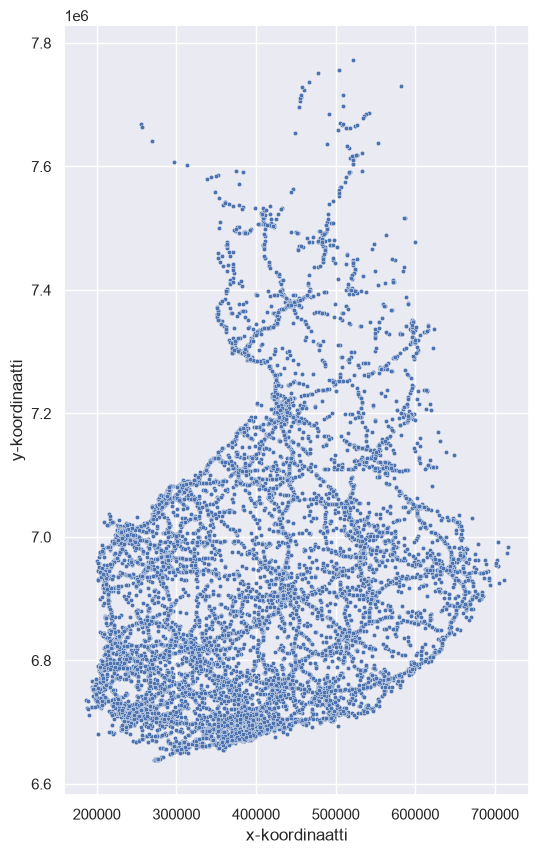

In [9]:
import seaborn as sns

sns.set_theme(rc={'figure.figsize':(6,10)})
sns.scatterplot(data=df_original, x="x-koordinaatti", y="y-koordinaatti", s=10)

## Datan esikäsittely Nur

In [10]:
df = pd.DataFrame(df_original)

In [11]:
df['Valoisa'] = df['Valoisuus'].map({'tie valaistu' : 1, 'pimeä (valaisematon)' : 0, 'päivänvalo' : 1, 'hämärä' : 0})

In [12]:
df['Taajama'] = df['Taajama'].map({'ei': 0, 'kyllä': 1, False: 0, True: 1})

In [13]:
df['Raskaan liikenteen onnettomuus'] = df['Raskaan liikenteen onnettomuus'].map({'ei': 0, 'kyllä': 1})

In [14]:
df['Sää'] = df['Sää'].map({'kirkas' : 1, 'lumisade' : 0, 'pilvipouta' : 1, 'raesade' : 0, 'vesisade' : 0, 'räntäsade' : 0,
 'sumu' : 0})

In [15]:
df['Kestopäällyste'] = df['Päällyste'].map({'kestopäällyste' : 1, 'sora' : 0, 'kivi' : 0, 'öljysora tai vast' : 0, 'muu' : 0, 'betoni' : 1})

In [16]:
# kuiva=0, märkä=1, luminen=2
df['Pinta'] = df['Pinta'].map({'jäinen' : 2, 'luminen' : 2, 'urissa vettä' : 1,
   'paljas, märkä' : 1, 'ajourat paljaat' : 2, 'paljas, kuiva' : 0, 'sohjoinen' : 2})

In [17]:
df['Onnettomuusluokka'] = df['Onnettomuusluokka'].map({'yksittäisonnettomuus' : 0, 'kääntymisonnettomuus' : 1, 'ohitusonnettomuus' : 2,
                                                       'risteämisonnettomuus' : 3,'kohtaamisonnettomuus' : 4, 'peräänajo-onnettomuus' : 5,
                                                       'mopedionnettomuus' : 6, 'polkupyöräonnettomuus' : 6, 'jalankulkijaonnettomuus' : 6, 'hirvionnettomuus' : 7,
                                                       'peura- tai kaurisonnettomuus' : 7, 'muu eläinonnettomuus' : 7, 'muu onnettomuus' : 8}).astype('Int64')

In [18]:
df['Onnettomuuspaikka_ajorata'] = df['Onnettomuuspaikka'].map(lambda x: 1 if x == 'ajorata' else 0)

In [19]:
# Ensimmäinen osuus
df.drop(columns=['OnnettomuusID', 'Tienpitäjä', 'Tieosoite', 'Ajorata', 'Tie', 'Osa', 'Etaisyys', 'ELY-keskus', 'Maakunta', 'Kunta', 'Katuosoite', 'Vuosi', 'Onnettomyystyyppi', 'Onnettomuustyyppi nro', 'Tietyö', 'Onnettomuuspaikka', 'Liittymäjärjestelyt', 'Viikonpäivä', 'Verkollinen asema', 'Talvihoitoluokitus', 'Toiminallinen luokka korjattu', 'Rautatie', 'Liikennevalot', 'Valoisuus', 'Päällyste', 'x-koordinaatti', 'y-koordinaatti', 'Kuukausi'], inplace=True)
df

,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Pinta,Lämpötila,Sää,Nopeusrajoitus,Taajama,Valoisa,Kestopäällyste,Onnettomuuspaikka_ajorata
0,Ei henkilövahinkoja,5,0.0,2.0,−25,1,100.0,0.0,0.0,1.0,1
1,Ei henkilövahinkoja,7,0.0,2.0,−30,1,80.0,0.0,0.0,1.0,1
2,Ei henkilövahinkoja,1,0.0,2.0,−15,1,40.0,1.0,1.0,1.0,1
3,Ei henkilövahinkoja,0,0.0,2.0,−19,1,40.0,1.0,0.0,1.0,1
4,Ei henkilövahinkoja,0,0.0,2.0,−20,1,30.0,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
27839,Ei henkilövahinkoja,1,NaN,2.0,?5,1,40.0,1.0,1.0,1.0,0
27840,Ei henkilövahinkoja,8,NaN,2.0,?3,1,50.0,1.0,1.0,1.0,1
27841,Ei henkilövahinkoja,3,NaN,2.0,?3,0,40.0,1.0,1.0,0.0,1
27842,Loukkaantumiseen johtanut,3,NaN,2.0,?7,1,60.0,0.0,1.0,1.0,1


In [20]:
df.dtypes

Vakavuus                              str
Onnettomuusluokka                   Int64
Raskaan liikenteen onnettomuus    float64
Pinta                             float64
Lämpötila                             str
Sää                                 int64
Nopeusrajoitus                    float64
Taajama                           float64
Valoisa                           float64
Kestopäällyste                    float64
Onnettomuuspaikka_ajorata           int64
dtype: object

In [21]:
df['Lämpötila'] = (df['Lämpötila'].str.replace('−', '-', regex=False).str.replace('?', '-', regex=False).astype(float)) # Korjataan "väärä" miinusmerkki
df

,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Pinta,Lämpötila,Sää,Nopeusrajoitus,Taajama,Valoisa,Kestopäällyste,Onnettomuuspaikka_ajorata
0,Ei henkilövahinkoja,5,0.0,2.0,-25.0,1,100.0,0.0,0.0,1.0,1
1,Ei henkilövahinkoja,7,0.0,2.0,-30.0,1,80.0,0.0,0.0,1.0,1
2,Ei henkilövahinkoja,1,0.0,2.0,-15.0,1,40.0,1.0,1.0,1.0,1
3,Ei henkilövahinkoja,0,0.0,2.0,-19.0,1,40.0,1.0,0.0,1.0,1
4,Ei henkilövahinkoja,0,0.0,2.0,-20.0,1,30.0,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
27839,Ei henkilövahinkoja,1,NaN,2.0,-5.0,1,40.0,1.0,1.0,1.0,0
27840,Ei henkilövahinkoja,8,NaN,2.0,-3.0,1,50.0,1.0,1.0,1.0,1
27841,Ei henkilövahinkoja,3,NaN,2.0,-3.0,0,40.0,1.0,1.0,0.0,1
27842,Loukkaantumiseen johtanut,3,NaN,2.0,-7.0,1,60.0,0.0,1.0,1.0,1


In [22]:
df['Vakavuus'] = df['Vakavuus'].map({'Ei henkilövahinkoja': 0, 'Loukkaantumiseen johtanut': 1, 'Kuolemaan johtanut' : 2, 'Vakavaan loukkaantumiseen johtanut' : 1})
df

,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Pinta,Lämpötila,Sää,Nopeusrajoitus,Taajama,Valoisa,Kestopäällyste,Onnettomuuspaikka_ajorata
0,0,5,0.0,2.0,-25.0,1,100.0,0.0,0.0,1.0,1
1,0,7,0.0,2.0,-30.0,1,80.0,0.0,0.0,1.0,1
2,0,1,0.0,2.0,-15.0,1,40.0,1.0,1.0,1.0,1
3,0,0,0.0,2.0,-19.0,1,40.0,1.0,0.0,1.0,1
4,0,0,0.0,2.0,-20.0,1,30.0,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
27839,0,1,NaN,2.0,-5.0,1,40.0,1.0,1.0,1.0,0
27840,0,8,NaN,2.0,-3.0,1,50.0,1.0,1.0,1.0,1
27841,0,3,NaN,2.0,-3.0,0,40.0,1.0,1.0,0.0,1
27842,1,3,NaN,2.0,-7.0,1,60.0,0.0,1.0,1.0,1


In [23]:
# one-hot encode the genetic_variant variable
df = pd.get_dummies(df, columns=['Pinta', 'Onnettomuusluokka'], dtype='int64')
df

,Vakavuus,Raskaan liikenteen onnettomuus,Lämpötila,Sää,Nopeusrajoitus,Taajama,Valoisa,Kestopäällyste,Onnettomuuspaikka_ajorata,Pinta_0.0,Pinta_1.0,Pinta_2.0,Onnettomuusluokka_0,Onnettomuusluokka_1,Onnettomuusluokka_2,Onnettomuusluokka_3,Onnettomuusluokka_4,Onnettomuusluokka_5,Onnettomuusluokka_6,Onnettomuusluokka_7,Onnettomuusluokka_8
0,0,0.0,-25.0,1,100.0,0.0,0.0,1.0,1,0,0,1,0,0,0,0,0,1,0,0,0
1,0,0.0,-30.0,1,80.0,0.0,0.0,1.0,1,0,0,1,0,0,0,0,0,0,0,1,0
2,0,0.0,-15.0,1,40.0,1.0,1.0,1.0,1,0,0,1,0,1,0,0,0,0,0,0,0
3,0,0.0,-19.0,1,40.0,1.0,0.0,1.0,1,0,0,1,1,0,0,0,0,0,0,0,0
4,0,0.0,-20.0,1,30.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27839,0,NaN,-5.0,1,40.0,1.0,1.0,1.0,0,0,0,1,0,1,0,0,0,0,0,0,0
27840,0,NaN,-3.0,1,50.0,1.0,1.0,1.0,1,0,0,1,0,0,0,0,0,0,0,0,1
27841,0,NaN,-3.0,0,40.0,1.0,1.0,0.0,1,0,0,1,0,0,0,1,0,0,0,0,0
27842,1,NaN,-7.0,1,60.0,0.0,1.0,1.0,1,0,0,1,0,0,0,1,0,0,0,0,0


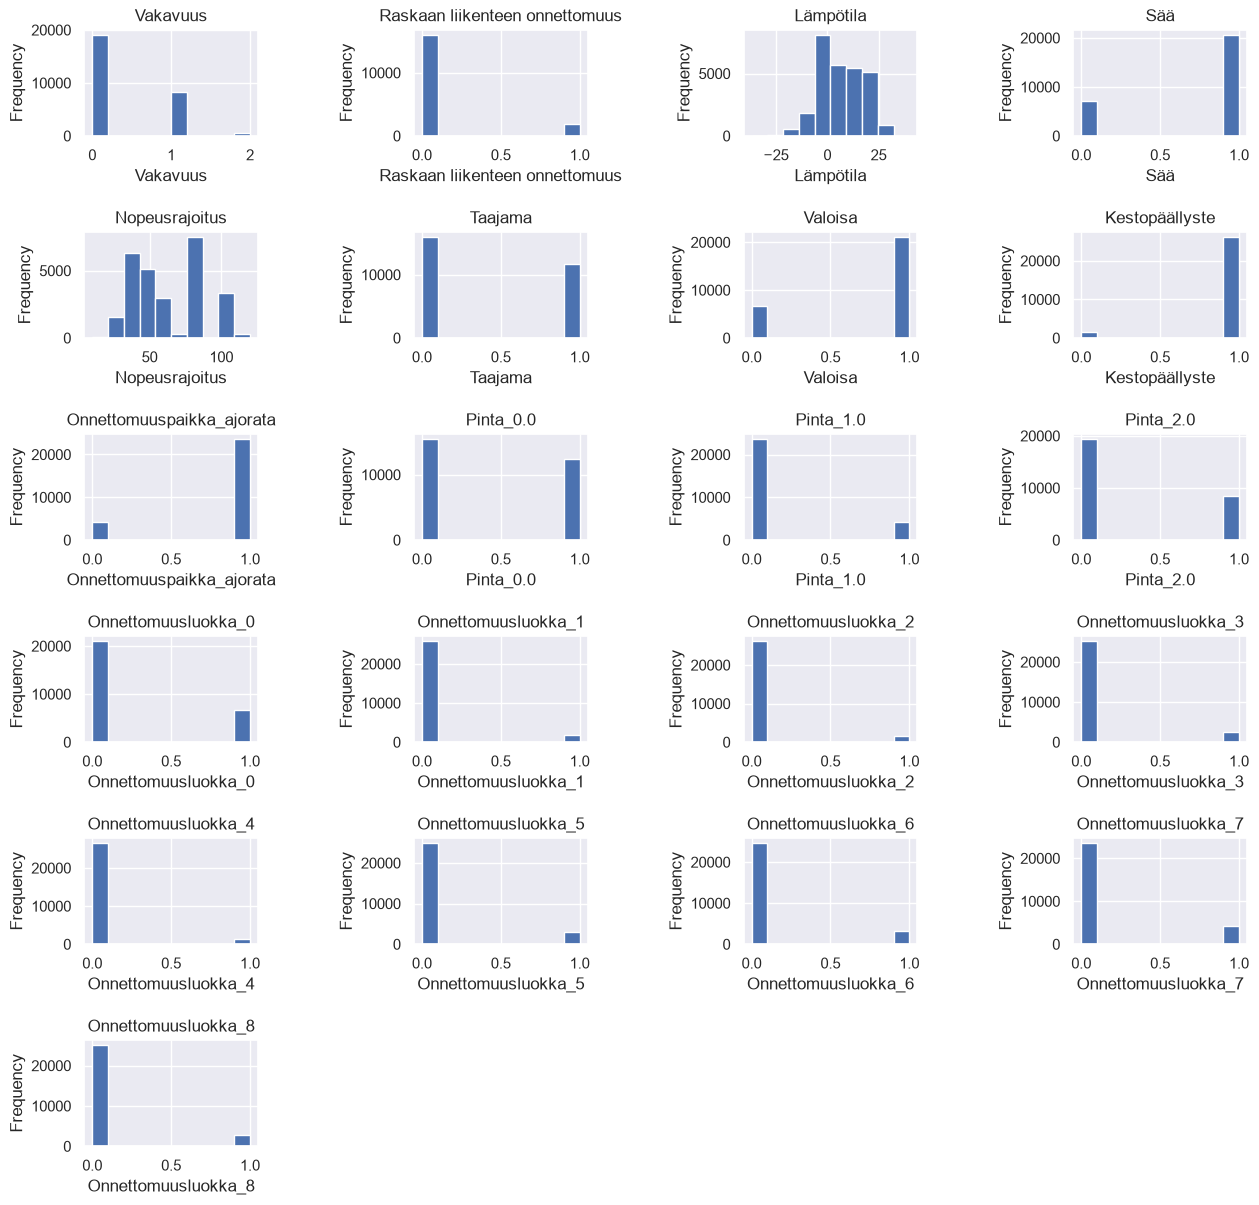

In [24]:
import matplotlib.pyplot as plt

def plot_data(df):
    plt.figure(figsize=(15, 25))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(10, 4, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)
        plt.subplots_adjust(hspace=0.9, wspace=0.9)

plot_data(df)

katsottiin pylväsdiagrammeista että ei ole outliers

In [25]:
y = df['Vakavuus']
X = df.drop(columns=['Vakavuus'])

## Vaihe 1: Voiko onnettomuuden vakavuuden ennustaa onnettomuuden ominaisuuksien perusteella? Anni

### Mallinnus

Käytimme validoinnissa `sklearn`:n tarjoamaa `train_test_split` metodia ositusvalidoinnin (split validation) toteuttamisessa. Jaoimme datan koulutusdataan (30%) ja testidataan (70%). Määritimme `stratify=y` luokkien epätasaisuuden vuoksi varmistaaksemme, että luokkien suhteelliset osuudet pysyvät samoina jaon jälkeen.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

print((y_train).value_counts(normalize=True))
print((y_test).value_counts(normalize=True))

Vakavuus
0    0.686711
1    0.294561
2    0.018728
Name: proportion, dtype: float64
Vakavuus
0    0.686617
1    0.294589
2    0.018793
Name: proportion, dtype: float64


Käytimme mallin rakentamiseen `sklearnin` tarjoamaa `RandomForestClassifier` luokkaa. Määritimme `max_samples` eli otosten määrän määrittävän parametrin ylärajaksi 0.75 ja `max_features` parametin ylärajaksi 0.65.

`Class_weight="balanced_subsample"` parametri määrittää, että harvinaisten luokkien virheet painavat yleisiä enemmän ja että painot lasketaan bootstrap otoksen perusteella puukohtaisesti. Tämä auttaa varmistamaan riittävän korkean saannon (recall).

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# Create a random forest classifier
model = RandomForestClassifier(max_samples=0.75, max_features=0.65, random_state=123, class_weight="balanced_subsample", min_samples_leaf=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

Confusion matrix:
[[4455 1123  158]
 [ 854 1483  124]
 [  32   69   56]]
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      5736
           1       0.55      0.60      0.58      2461
           2       0.17      0.36      0.23       157

    accuracy                           0.72      8354
   macro avg       0.52      0.58      0.54      8354
weighted avg       0.74      0.72      0.73      8354



`classification_report`:n mukaan mallin `accuracy` eli tarkkuus on 72%, mutta Luokkien epätasaisuuden vuoksi tarkkuus ei yksinään riitä mallin suorituskyvyn tulkitsemiseen.

Malli tunnistaa parhaiten onnettomuudet, jossa ei satu henkilövahinkoja. Malli tunnisti tälläiset tapaukset oikein 83% ajasta. Henkilöonnettomuudet se tunnistaa 55% ajasta ja kuolemaan johtaneet onnettomuudet vain 17% ajasta. Mallin saanto on 78% onnettomuuksille ilman henkilövahinkoja, 60% henkilövahingoille ja 36% kuolemille. Malli tunnistaa siis onnettomuudet ilman henkilövahinkoja paljon paremmin, kuin loukkaantumiset.

In [28]:
# Display the feature importances
for value, name in zip(model.feature_importances_, model.feature_names_in_):
    print(name + ":  " + str(value))

Raskaan liikenteen onnettomuus:  0.07060162499629563
Lämpötila:  0.2814445892017798
Sää:  0.04159165971803744
Nopeusrajoitus:  0.1328678197292728
Taajama:  0.02528017593213139
Valoisa:  0.02890571470620012
Kestopäällyste:  0.022740110180304102
Onnettomuuspaikka_ajorata:  0.022830925077400924
Pinta_0.0:  0.025615126432725503
Pinta_1.0:  0.026099563488626118
Pinta_2.0:  0.020344709628597833
Onnettomuusluokka_0:  0.03035363974989975
Onnettomuusluokka_1:  0.009077155492777716
Onnettomuusluokka_2:  0.012545129641318972
Onnettomuusluokka_3:  0.011477075683116898
Onnettomuusluokka_4:  0.0659115203604374
Onnettomuusluokka_5:  0.012964113661183019
Onnettomuusluokka_6:  0.0747586859956838
Onnettomuusluokka_7:  0.06939015415293993
Onnettomuusluokka_8:  0.015200506171270882


Muuttujien tärkeyksien mukaan onnettomuuden vakavuutta selittää eniten onnettomuusluokka ja lämpötila. Onnettomuusluokan yhteenlaskettu tärkeys on noin 30% ja lämpötilan noin 28%. Nämä kaksi muuttujaa kattavat jo melkein 60% mallin käytämästä datasta. Kolmanneksi tärkein muuttuja oli nopeusrajoitus noin 13% tärkeydellä. 

Seuraavaksi tärkeimpiä on raskaan liikenteen osuus (noin 7%) ja tienpintojen yhteenlaskettu tulos (noin 7%). Loput muuttujat jäivät alle 5%, eli niitä on huomioitu selvästi vähemmän jakokohdissa.

Kolmen luokan mallissa kuolemaan johtaneiden tapausten harvinaisuus vaikutti negatiivisesti mallin kykyyn luokitella liikenneonnettomuuden vakavuutta. Kokeilimme mallin suorituskykyä binääriluokittelijana yhdistämällä kuolemaan johtaneet tapauksen muiden henkilövahinkojen kanssa.

In [29]:
y[y == 2] = 1

y.unique()

array([0, 1])

Nyt vastemuuttujat ovat binäärimuodossa: ei henkilövahinkoja (0) ja henkilövahingot (1). Jätimme mallin luonnissa pois paramentrin `class_weight="balanced_subsample"` koska datassa ei ollut yhtä vahvaa epäbalanssia. Seuraavaksi jaoimme datan uudestaan koulutus- ja testidataan ja koulutimme mallin.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

Confusion matrix:
[[4571 1166]
 [ 896 1721]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      5737
           1       0.60      0.66      0.63      2617

    accuracy                           0.75      8354
   macro avg       0.72      0.73      0.72      8354
weighted avg       0.76      0.75      0.76      8354



Malli luokitteli havainnot oikein 75% tarkkuudella. 

Mallin tunnistamat henkilöonnettomuudet olivat oikein 60% ajasta, osoittaen 5% parannusta verraten kolmen luokan malliin. Henkilöonnettomuus luokan täsmällisyys parani noin 5% ja saanto noin 6%. Luokittelu parani myös niiden onnettomuuksien osalta, jossa ei esiintynyt henkilövahinkoja. 

`Confusion matrix` perusteella malli löytää noin kaksi kolmasosaa todellisista tapaturmista. Noin 34% eli 896 tapausta jää tunnistamatta.

# Display the feature importances
for value, name in zip(model.feature_importances_, model.feature_names_in_):
    print(name + ":  " + str(value))

Muuttujien tärkeyksissä onnettomuusluokka on selkeästi tärkein ja sen merkitys kasvoi kolmen luokan mallista noin 22%. Onnettomuusluokkien yhteenlaskettu tärkeys on noin 52% kattaen yli puolet mallin käyttämästä datasta. Onnettomuusluokista tärkein oli luokka 6, joka kuvaa kevyenliikenteen onnettomuuksia. 

Edelliseen malliin verraten lämpötilan tärkeys laski noin 7% ja nopeusrajoituksen noin 3%. Muut muuttujat jäivät alle 5%. Tärkeysjärjestys pysyy mallien kesken suunnilleen  samana, mutta painoarvot vaihtelevat hieman eri piirteiden välillä. 

### Arviointi

## Vaihe 2: Miten ensiapuyksiköt pitäisi sijoittaa Uudellamaalla, jotta onnettomuuksiin voidaan reagoida mahdollisimman tehokkasti? Riikka

### Mallinnus

Optimaalisten sijaintien löytämiseen ensiapuyksiköille Uudellamaalla käytetään klusterointia. Alkuperäisestä yhdistetystä datasetistä otetaan klusterointiin mukaan vain ne onnettomuusnäytteet, jotka ovat tapahtuneet Uudellamaalla ja jotka ovat vakavuudeltaan luokiteltu "Loukkaantumiseen johtanut", "Vakavaan loukkaantumiseen johtanut" tai "Kuolemaan johtanut". 

In [31]:
uusimaa = df_original[df_original["Maakunta"] == "Uusimaa"]
uusimaa = uusimaa[(uusimaa["Vakavuus"] == "Loukkaantumiseen johtanut") | (uusimaa["Vakavuus"] == "Vakavaan loukkaantumiseen johtanut") | (uusimaa["Vakavuus"] == "Kuolemaan johtanut")]
uusimaa

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,ELY-keskus,Maakunta,Kunta,Katuosoite,Vuosi,Kuukausi,Onnettomyystyyppi,Onnettomuustyyppi nro,Vakavuus,Onnettomuusluokka,Raskaan liikenteen onnettomuus,Tietyö,Onnettomuuspaikka,Liittymäjärjestelyt,Viikonpäivä,Pinta,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
31,630383,Kunta,NaN,NaN,NaN,NaN,NaN,392017.0,6685318.0,NaN,Uudenmaan ELY,Uusimaa,Vantaa,Kuninkaalantie 2,2024,1,kohtaaminen kaarteessa,21,Loukkaantumiseen johtanut,kohtaamisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ti,luminen,päivänvalo,−18,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
38,630390,Kunta,NaN,NaN,NaN,NaN,NaN,392858.0,6681503.0,NaN,Uudenmaan ELY,Uusimaa,Helsinki,TATTARIHARJUNTIE,2024,1,peräänajo jarruttavaan ajoneuvoon,6,Loukkaantumiseen johtanut,peräänajo-onnettomuus,kyllä,ei,ajorata,linjaonnettomuus,ke,jäinen,päivänvalo,−17,pilvipouta,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
39,630391,Väylävirasto,1371/1/648,0.0,1371.0,1.0,648.0,389089.0,6687040.0,NaN,Uudenmaan ELY,Uusimaa,Vantaa,JUNKERSINTIE,2024,1,kohtaaminen kaarteessa,21,Loukkaantumiseen johtanut,kohtaamisonnettomuus,ei,ei,ajorata,linjaonnettomuus,ke,jäinen,tie valaistu,−20,lumisade,50.0,Tieto puuttuu,muu,Ise,Yhdystie,Ei tasoristeystä,kyllä
51,630403,Kunta,NaN,NaN,NaN,NaN,NaN,383665.0,6671405.0,toiminnassa,Uudenmaan ELY,Uusimaa,Helsinki,PORKALANKATU X TALLBERGINKATU,2024,1,suistuminen tieltä risteyksessä,86,Loukkaantumiseen johtanut,yksittäisonnettomuus,ei,kyllä,ajorata,liikennevalot,ke,jäinen,tie valaistu,−17,kirkas,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
77,630432,Väylävirasto,130/4/5,0.0,130.0,4.0,5.0,379482.0,6697489.0,NaN,Uudenmaan ELY,Uusimaa,Nurmijärvi,HÄMEENLINNANTIE X METSÄKYLÄNTIE,2024,1,"muu risteämisonnettomuus, ei kääntymistä",49,Loukkaantumiseen johtanut,risteämisonnettomuus,ei,ei,ajorata,STOP-merkki,to,luminen,tie valaistu,−20,pilvipouta,80.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27525,620277,Väylävirasto,222890,1.0,1.0,4.0,2510.0,376507.0,6676445.0,NaN,Uudenmaan ELY,Uusimaa,Espoo,TIE 1,2022,12,peräänajo jarruttavaan ajoneuvoon,6,Loukkaantumiseen johtanut,peräänajo-onnettomuus,False,False,ajorata,linjaonnettomuus,to,"paljas, märkä",pimeä (valaisematon),2,vesisade,80.0,Keskustan ohikulku kaava-alueella,kestopäällyste,Ise,Valtatie,Ei tasoristeystä,False
27640,620397,Kunta,NaN,NaN,NaN,NaN,NaN,384773.0,6673841.0,ei toiminnassa,Uudenmaan ELY,Uusimaa,Helsinki,MANNERHEIMINTIE X SALLINKATU,2022,12,suistuminen tieltä risteyksessä,86,Loukkaantumiseen johtanut,yksittäisonnettomuus,False,False,suojatie,liikennevalot,ma,jäinen,tie valaistu,?1,pilvipouta,50.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True
27643,620400,Kunta,NaN,NaN,NaN,NaN,NaN,385174.0,6670391.0,NaN,Uudenmaan ELY,Uusimaa,Helsinki,EIRANRANTA X HERNESAARENRANTA,2022,12,"muu risteämisonnettomuus, ei kääntymistä",49,Loukkaantumiseen johtanut,risteämisonnettomuus,False,False,ajorata,tasa-arvo,ma,jäinen,tie valaistu,?5,pilvipouta,30.0,NaN,kestopäällyste,NaN,NaN,Ei tasoristeystä,True
27685,620445,Väylävirasto,101/8/2929,1.0,101.0,8.0,2929.0,393637.0,6677829.0,vilkulla,Uudenmaan ELY,Uusimaa,Helsinki,KEHÄ 1 X MYLLYPURONTIE,2022,12,"muu risteämisonnettomuus, ei kääntymistä",49,Loukkaantumiseen johtanut,risteämisonnettomuus,False,False,ajorata,liikennevalot,ke,"paljas, märkä",tie valaistu,0,kirkas,60.0,Tieto puuttuu,kestopäällyste,Ise,Seututie,Ei tasoristeystä,True


Suodatuksen jälkeen klusterointia varten on 1836 näytettä. Nämä näytteet mallinnetaan `scatterplot`-kaaviona, eli pistekaaviota, kaikkien alkuperäisessä datasetissä olevien näytteiden kanssa. Kaavion luomiseen käytetään `Seaborn`-kirjaston `scatteplot`-funktiota.

<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

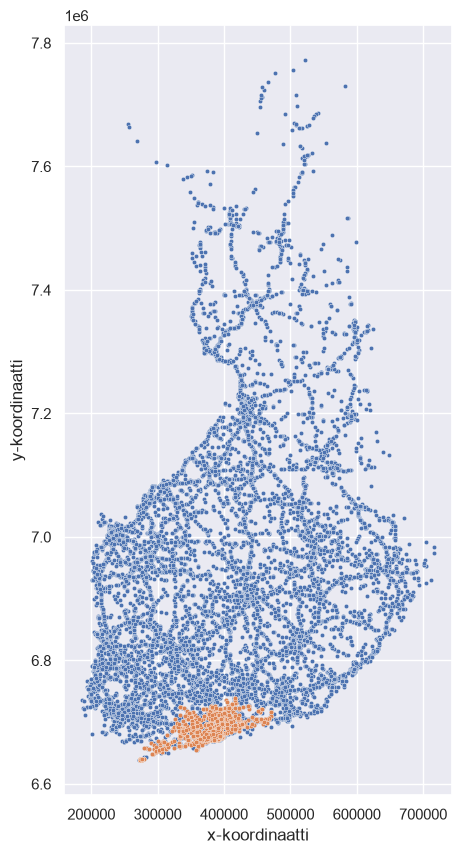

In [32]:
import seaborn as sns

sns.set_theme(rc={'figure.figsize':(5,10)})
ax = sns.scatterplot(data=df_original, x="x-koordinaatti", y="y-koordinaatti", s=10)
sns.scatterplot(data=uusimaa, x="x-koordinaatti", y="y-koordinaatti", s=10, ax=ax)

Pistenkaaviossa näkyy oranssilla Uudellamaalla sattuneet loukkaantumiseen tai kuolemaan johtaneet liikenneonnettomuudet. Sinisellä on merkitty kaikki muut liikenneonnettomuudet, eli kaikki ne, jotka ovat tapahtuneet Uudenmaan ulkopuolella sekä ne, jotka ovat tapahtuneet Uudellamaalla, mutta eivät ole aiheuttaneet henkilövahinkoja.

Seuraavassa pistekaaviossa on esitetty tarkemmin klusterointiin käytettävät näytteet, eli se on lähikuva ylemmän pistekaavion oransseista pisteistä.

<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

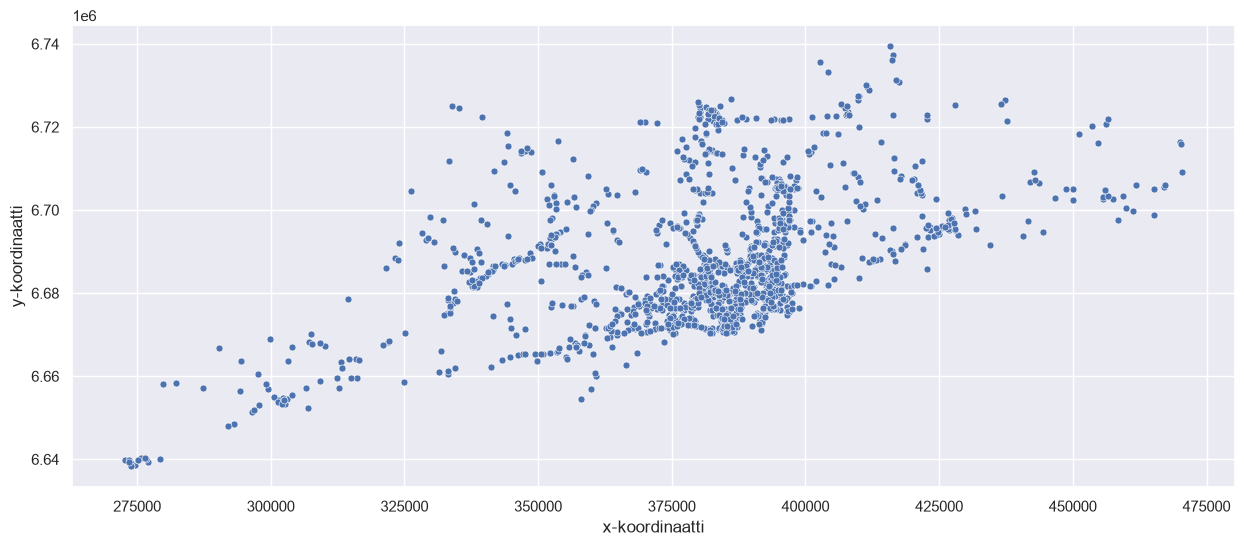

In [33]:
sns.set_theme(rc={'figure.figsize':(15, 6)})
sns.scatterplot(data=uusimaa, x="x-koordinaatti", y="y-koordinaatti", s=25)

Kaaviosta nähdään, että pisteitä on tiheämmin alareunassa keskellä ja harvemmin ylhäällää sen ympärillä. Kun tätä tietoa verrantaan Uudenmaan karttoihin, huomataan, että alue jolle pisteet ovat keskittyneet tiiviimmin, on pääkaupunkiseutu. Voidaan siis päätellä, että pääkaupunkiseudulla tapahtuu enemmän liikenneonnettomuuksia kuin sitä ympäröivillä alueilla.

Klusterointia varten datasetistä erotettiin `x-koordinaatti`- ja `y-koordinaatti`-sarakkeet uuteen `DataFrame`-olioon. Näissä oli joukossa puuttuvia arvoja, eli kaikille onnettomuuksille ei ollut annettu tarkkoja sijaintietoja. Nämä näytteet poistettiin `dropna`-metodilla, sillä klusterointiin käytettävät mallit eivät pysty käsittelemään niitä. Klusterointia varten jäi 1828 näytettä.

In [34]:
coordinates = uusimaa.loc[:, ['x-koordinaatti', 'y-koordinaatti']]
coordinates.dropna(how='any', inplace=True)
coordinates

,x-koordinaatti,y-koordinaatti
31,392017.0,6685318.0
38,392858.0,6681503.0
39,389089.0,6687040.0
51,383665.0,6671405.0
77,379482.0,6697489.0
...,...,...
27525,376507.0,6676445.0
27640,384773.0,6673841.0
27643,385174.0,6670391.0
27685,393637.0,6677829.0


Optimaalisten sijaintien ja alueiden muodostamiseen käytetään kahta eri klusterointimallia: KMeans ja hierarkinen. Näiden tuloksia verrataan, että voidaan päättää, miten alueet olisi järkevintä muodostaa. 

`Scikit learn`-kirjasto tarjoaa `KMeans`-luokan, joka toimii klusterointimallina. Haluttujen klusterin määrä koodataan omaan muutujaan, jotta sitä voidaan helposti käyttää myös hierarkisessa klusteroinnissa. Mallin `n_clusters`-parametri kertoo, kuinka monta klusteria halutaan muodostaa, `init`-parametri määrittää, mihin ensimmäiset klusterien keskipisteet asetetaan. Tässä on käytetty `random`-arvoa, eli keskipisteet valitaan sattumanvaraisesti. Viimeinen `random_state`-parametrin määrittäminen mahdollistaa samojen tulosten saamisen eri kerroilla, kun käytetään samaa arvoa, vaikka `init`-parametrin arvo olisi `random`.

Mallille annetaan klusterointia varten näytteet, eli tässä tapauksessa koordinaatit, `fit`-metodilla. Malli suorittaa näytteille klusteroinnin.

In [ ]:
from sklearn.cluster import KMeans
n_clusters = 5

model = KMeans(init='random', n_clusters=n_clusters, random_state=42)
model.fit(coordinates)

Klusterien keskipisteiden koordinaatit saadaan mallilta `cluster_centers_`-metodilla. Koordinaatit kerätään uuteen `DataFrame`-olioon.

In [ ]:
centroids = model.cluster_centers_
centroids_df = pd.DataFrame(centroids)
centroids_df

Näytteiden klusteriluokat saadaan mallilta `labels_`-metodilla, ja ne kerätään uuteeen `DataFrame`-olioon. Nämä tiedot liitetään näytteisiin, eli jokaiselle näytteelle lisätään tieto siitä, mihin klusteriin tai alueeseen se kuuluu.

In [ ]:
labels = model.labels_
coordinates_alueet = pd.DataFrame(coordinates)
coordinates_alueet['Alue'] = labels

Näytteet mallinnetaan pistekaavioon. Antamalla `scatterplot`-funktiolle `hue`-parametriin klusteritiedon sisältävän sarakkeen nimen, mallinnetut näytteet pisteet erotetaan klusterien perusteella toisistaan. Samaan klusteriin kuuluvat näytteet ovat siis samanvärisiä. Klusterien keskipisteen mallinnetaan myös pistekaavioon. Ne on merkitty keltaisina timantteina.

In [ ]:
ax = sns.scatterplot(data=coordinates_alueet, x="x-koordinaatti", y="y-koordinaatti", s=25, hue='Alue', palette="tab10")
sns.scatterplot(data=centroids_df, x=0, y=1, s=50, ax=ax, marker='D', color='yellow')

Pistekaaviosta nähdään, että, kun luodaan viisi klusteria, tiheästi keskellä alareunassa olevat pisteet muodostavat oman klusterin, ja sen ympärille kummallekin puolelle muodostuu kaksi klusteria. Keskimmäinen klusteri vaikuttaisi olevan, kun verrataan karttaan, pääkaupunkiseutu. Sen yläpuolella oikealla oleva sinisellä merkitty klusteri vastaa suunilleen muuta Keski-Uudenmaan aluetta. Oranssilla merkitty klusteri vaikuttaisi täsmäävän Itä-Uudenmaan aluetta, ja vihreällä ja violetilla merkityt klusterit vastaavan Länsi-Uudenmaan aluetta.

`Scikit learn`-kirjaston funktiolla saadaan `Silhouette score`-arvo, joka kertoo, miten hyvin näytteet on lajiteltu klustereihin. Tulos annetaan välillä -1 ja 1. Mitä lähempänä arvo on 1:stä, sitä tiheämmät ja toisistaan hyvin erillään klusterit ovat. Lähempänä -1:stä oleva tulos kertoo, että klusterit eivät ole hyvin jakautuneet, eli klusterointi ei ole toimiva. 

In [ ]:
from sklearn.metrics import silhouette_score

print('Silhouette score = %.2f' % silhouette_score(coordinates_alueet, labels))

Viidellä klusterilla `Silhouette score`-arvo on 0.53. Se ei ole loistava muttei myöskään huono tulos. Klusterit ovat siis suhteellisen hyvin toisistaan erillään ja tiiviitä.

Toinen tekniikalla, jolla voidaan arvioida `KMeans`-mallin klusteroinnin tehokkuutta, on `inertia`, tai "within-cluster sum of squared distances (WCSS)". Se mittaa, miten lähellä ja tiiviisti näytteet/pisteet ovat klusterinsa keskipistettä. Inertia laskee, kun klustereita on enemmän, joten tavoitteena ei ole asettaa klusterien määräksi mahdollisimman suurta lukua, vaan löytää se kohta, missä inertia nopean laskun jälkeen tasaantuu. Tätä kutsutaan `elbow`-metodiksi. Inertian laskemiseen mallilla on oma metodi, `inertia_`. Seuraavassa kaaviossa on esitetty, miten inertian arvon laskeminen, kun klusterien määrää kavatetaan yhdestä viiteentoista.

In [ ]:
import matplotlib.pyplot as plt

sns.set_theme(rc={'figure.figsize':(10,6)})
wcss = []
for i in range(1,16):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(coordinates)
    wcss.append(model.inertia_)
    
plt.plot(range(1,16), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Kaavion perusteella paras lukumäärä klustereille olisi noin viisi kappaletta.

Klusterointia testataan myös hierarkisella klusteroinnilla. `Scikit learn`-kirjasto tarjoaa myös tälle tekniikalle oman luokan, `AgglomerativeClustering`, joka toimii klusterointimallina. Se ottaa parametrina `n_clusters` klusterien lukumäärän. Mallille annetaan näytteet, eli koordinaatit, ja se antaa takaisin näytteiden klusteriluokat, kun käytetään mallin `fit_predict`-metodia. Klusteriluokat liitetään näytteisiin, eli jokainen näyte saa tiedon siitä, mihin klusteriin se kuuluu.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=n_clusters)
labels = model.fit_predict(coordinates)
coordinates['Alue'] = labels
coordinates

Hierarkisessa klusteroinnissa käytettävä malli ei erikseen muodosta klusterien keskipisteitä, joten ne täytyy laskea manuaalisesti. Tämä tehdään laskemalla jokaisen klusterin näytteiden koordinaattien keskiarvo. Lasketut koordinaatit kerätään listaan, josta muodostetaan `DataFrame`-olio.

In [ ]:
centers = []

for x in range(n_clusters):
    samples = coordinates[coordinates['Alue'] == x]
    centers.append((samples['x-koordinaatti'].mean(), samples['y-koordinaatti'].mean()))
    
hier_df = pd.DataFrame(centers)
hier_df

Näytteet mallinnetaan pistekaavioon. Samaan klusteriin kuuluvat näytteet ovat siis samanvärisiä. Klusterien keskipisteen mallinnetaan myös pistekaavioon. Ne on merkitty keltaisina timantteina.

In [ ]:
sns.set_theme(rc={'figure.figsize':(15, 6)})
ax = sns.scatterplot(data=coordinates, x="x-koordinaatti", y="y-koordinaatti", s=25, hue='Alue', palette="tab10")
sns.scatterplot(data=hier_df, x=0, y=1, s=50, ax=ax, marker='D', color='yellow')

Klusterit vaikuttavat, kun tehdään viisi klusteria, muodostuvan aikalailla samanlailla kuin KMeans-mallia käytettäessä. Pientä eroa on, mutta pääosin ne näyttävät aika samoilta. Suuremilla klusterimäärillä ero oli selkeämpää.

Hierarkisen klusterointimallin toimivuutta tukitaan myös `Silhouette score`-arvolla.

In [ ]:
print('Silhouette score = %.2f' % silhouette_score(coordinates, labels))

Viidellä klusterilla tulos on 0.52, eli tulos on lähes yhtä hyvä kuin KMeans-mallilla.

Alla olevaan taulukkoon on kerätty kummankin mallin `Silhouette score`-tuloksia klusterien lukumäärille kolmesta kymmeneen.

| Klusterit | KMeans Silhouette score | Hierarkinen Silhouette score |
|-----------|-------------------------|------------------------------|
| 3         | 0.50                    | 0.50                         |
| 4         | 0.51                    | 0.51                         |
| 5         | 0.53                    | 0.52                         |
| 6         | 0.46                    | 0.43                         |
| 7         | 0.42                    | 0.37                         |
| 8         | 0.40                    | 0.37                         |
| 9         | 0.39                    | 0.36                         |
| 10        | 0.39                    | 0.37                         |

Taulukosta nähdään, että viisi klusteria antaa parhaan tuloksen kummallakin mallilla, eli viisi klusteria voisi olla paras ratkaisu, kun halutaan jakaa Uusimaa alueisiin liikenneonnetomuuksien sijaintien perusteella. Suuremmat klusterimäärät antavat huonompia tuloksia, eli klusterit eivät ole yhtä hyvin muodostuneita. Tämä voi johtua siitä, että näytteet ovat aika tiiviisti joissakin kohdissa, joten niitä on hankala lajitella selkeästi tiettyyn klusteriin, kun kohtia yritetään jakaa pienempiin osiin.

### Arviointi

Viidellä klusterilla mallit antavat parhaat `Silhouette score`-tulokset, 0.53 ja 0.52, ja `KMeans`-mallin inertiaa tutkittaessa `elbow`-metodilla viisi klusteria vaikuttaa olevan se kohta, jossa inertian lasku tasaantuu. Näiden tulosten perusteella Uusimaa olisi järkevintä jakaa viiteen alueeseen, joissa ensiapuyksiköt päivystäisivät.

Kumpikin malli antaa suurinpiirtein samat keskipisteet klustereille ja tomivuutta mittaavat tulokset eivät myöskään eroa paljon toisistaan, vaikka klusterien lukumäärää kasvatettaisiin, joten mallit eivät selkeästi anna toisistaan poikkeavia tietoja, joiden perusteella voitasiin valita parempi ratkaisu Uudenmaan jakamiselle päivystysalueisiin ja niiden keskipisteiden valitsemiseen. 

Vaikka mallien perusteella viisi klusteria olisi paras ratkaisu Uudenmaan jakamisesta eri päivystysalueiksi, täytyy aluejakoa ja sairaaloiden sekä ensiapuyksiköiden sijoittamisessa huomioida mm., miten alueilla pääsee liikkumaan, mihin ensiapuyksiköitä pystyy sijoittamaan, kuinka paljon resursseja on, ja kuinka paljon kustannuksia syntyy. Näiden perusteella voisi harkita Uudenmaan jakamista pienempiin päivystyalueisiin ja ensiapuyksiköiden lisäämistä, jotta liikenneonnetomuuksiin reagointi tehostuisi. 

Täytyy myös huomioida, että klusterointidatana on käyttetty vain liikenneonnettomuuksien, joissa on loukkaantunut tai kuollut henkilöitä, sijainteja. Ei ole realistista olettaa, että sairaaloita ja terveysasemia rakennettaisiin ja sijoitettaisiin siten, että ne auttaisivat erityisesti liikenneonnettomuuksissa loukkaantuneita. 

## Käyttöönotto Sandra